### Подготовка окружения

In [24]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate, UncorrelatedGaussianNoise, read_wave, Wave

In [26]:
PI2 = np.pi * 2

def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

def dct_iv(ys):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

## Упражнение 6.1

В этой главе утверждается, что `analyze1` требует времени, пропорционального $n^3$, а `analyze2` — $n^2$. Проверим это, замеряя время выполнения для разных размеров входных данных. Также протестируем `dct_iv` и `scipy.fftpack.dct`.

In [27]:
signal = UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)
noise.ys.shape

(16384,)

In [28]:
from scipy.stats import linregress

loglog = dict(xscale='log', yscale='log')

def plot_bests(ns, bests, label=''):
    plt.plot(ns, bests, label=label)
    decorate(**loglog)
    x = np.log(ns)
    y = np.log(bests)
    slope = linregress(x, y)[0]
    return slope

In [29]:
ns = 2 ** np.arange(6, 13)
ns

array([  64,  128,  256,  512, 1024, 2048, 4096])

In [30]:
def run_speed_test(ns, func):
    results = []
    for N in ns:
        print(N)
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = noise.ys[:N]
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)
    bests = [result.best for result in results]
    return bests

64
337 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
128
2.83 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
256
9.43 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
512
51.4 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
1024
142 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
937 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
4096
4.79 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(2.2154619507266267)

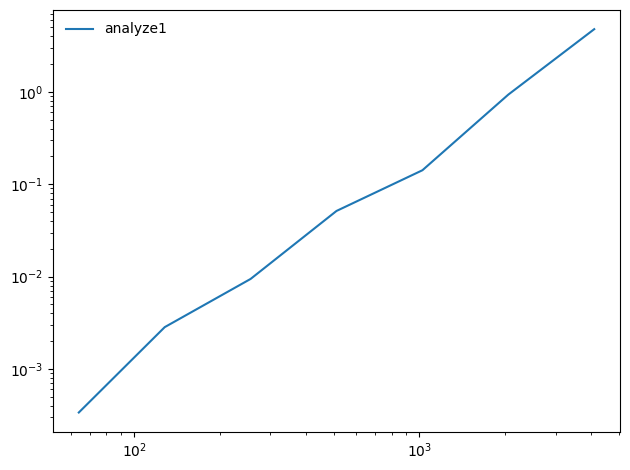

In [31]:
bests1 = run_speed_test(ns, analyze1)
slope1 = plot_bests(ns, bests1, label='analyze1')
slope1

Оценка наклона близка к 2, а не к 3, как ожидалось. Возможно, производительность `np.linalg.solve` в этом диапазоне размеров почти квадратична.

64
226 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
128
701 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
256
2.78 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
512
11.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
78 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
229 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
4096
764 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(2.024596617067688)

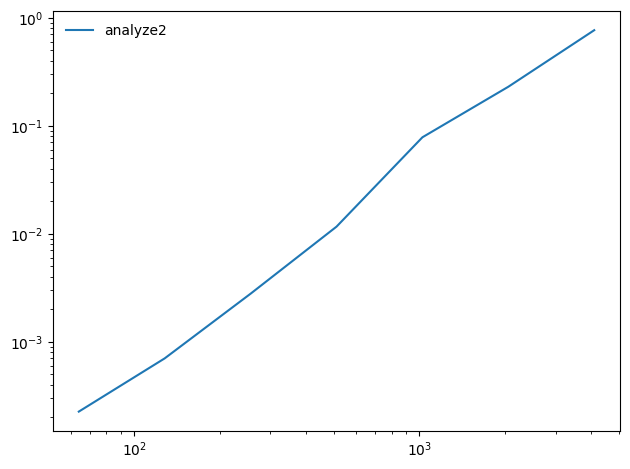

In [32]:
bests2 = run_speed_test(ns, analyze2)
slope2 = plot_bests(ns, bests2, label='analyze2')
slope2

Результаты для `analyze2` дают линию с наклоном, близким к 2, как и ожидалось.

64
15.1 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
128
15.6 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
256
17.4 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
512
22.1 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
1024
26.9 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
2048
40.3 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
4096
70 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)


np.float64(0.3576613496227337)

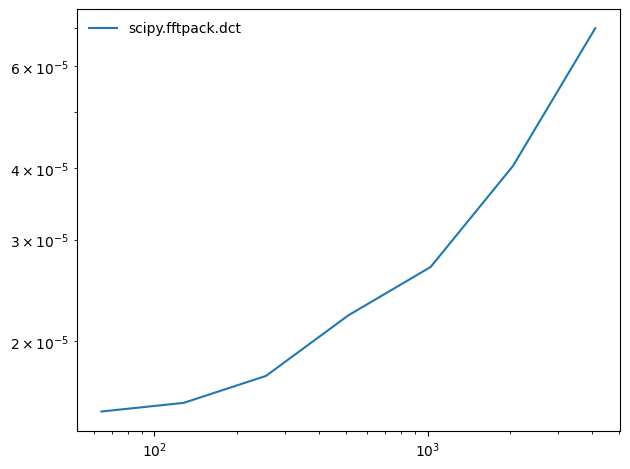

In [33]:
import scipy.fftpack

def scipy_dct(ys, freqs, ts):
    return scipy.fftpack.dct(ys, type=3)

bests3 = run_speed_test(ns, scipy_dct)
slope3 = plot_bests(ns, bests3, label='scipy.fftpack.dct')
slope3

`scipy.fftpack.dct` значительно быстрее. Кривая изогнута, что указывает на сложность $O(n \log n)$.

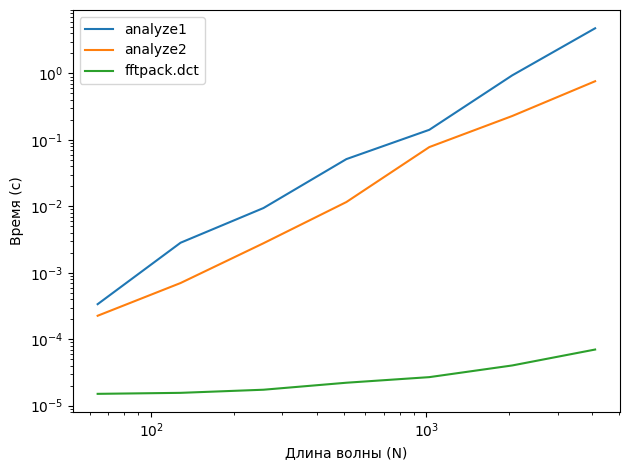

In [34]:
plt.plot(ns, bests1, label='analyze1')
plt.plot(ns, bests2, label='analyze2')
plt.plot(ns, bests3, label='fftpack.dct')
decorate(xlabel='Длина волны (N)', ylabel='Время (с)', **loglog)
plt.legend()

## Упражнение 6.2

Одно из главных применений DCT — сжатие звука и изображений. Реализуем простой алгоритм сжатия на основе DCT:

1. Разобьём сигнал на сегменты.
2. Вычислим DCT каждого сегмента.
3. Обнулим компоненты с малой амплитудой.
4. Восстановим сигнал через обратное DCT.

In [35]:
wave = read_wave('../code/100475__iluppai__saxophone-weep.wav')
wave.make_audio()

In [36]:
segment = wave.segment(start=0, duration=1)
segment.normalize()
segment.make_audio()

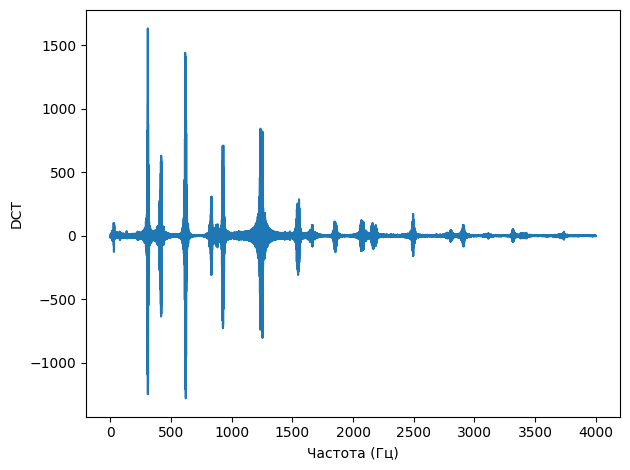

In [37]:
seg_dct = segment.make_dct()
seg_dct.plot(high=4000)
decorate(xlabel='Частота (Гц)', ylabel='DCT')

In [38]:
def compress(dct, thresh=1):
    count = 0
    for i, amp in enumerate(dct.amps):
        if np.abs(amp) < thresh:
            dct.hs[i] = 0
            count += 1
    n = len(dct.amps)
    print(f'Обнулено: {count} из {n} ({100 * count / n:.1f}%)')

Попробуем разные пороги и послушаем результат.

In [39]:
for thresh in [1, 10, 50, 100]:
    seg_dct = segment.make_dct()
    compress(seg_dct, thresh=thresh)
    seg2 = seg_dct.make_wave()
    display(seg2.make_audio())

Обнулено: 30815 из 44100 (69.9%)


Обнулено: 40365 из 44100 (91.5%)


Обнулено: 43222 из 44100 (98.0%)


Обнулено: 43704 из 44100 (99.1%)


При пороге 10 обнуляется более 90% компонентов, но разница почти незаметна на слух. При пороге 50 слышны искажения. При пороге 100 качество заметно ухудшается.

Теперь применим DCT-спектрограмму: разобьём сигнал на сегменты и применим сжатие к каждому.

In [40]:
def compress_wave_dct(wave, seg_length=1024, thresh=10):
    window = np.hamming(seg_length)
    n = len(wave.ys)
    step = seg_length // 2
    result = np.zeros(n)
    overlap = np.zeros(n)
    for i in range(0, n - seg_length + 1, step):
        segment = wave.slice(i, i + seg_length)
        segment.window(window)
        dct = segment.make_dct()
        compress(dct, thresh=thresh)
        seg2 = dct.make_wave()
        result[i:i + seg_length] += seg2.ys
        overlap[i:i + seg_length] += 1
    overlap[overlap == 0] = 1
    result /= overlap
    return Wave(result, framerate=wave.framerate)

print('Сжатие с порогом 10 (overlap-add):')
compressed_wave = compress_wave_dct(wave, seg_length=1024, thresh=10)
compressed_wave.make_audio()

Сжатие с порогом 10 (overlap-add):
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1024 из 1024 (100.0%)
Обнулено: 1023 из 1024 (99.9%)
Обнуле

In [41]:
print('Исходный сигнал для сравнения:')
wave.make_audio()

Исходный сигнал для сравнения:


При пороге 10 сжатие заметно, однако игра на инструменте на аудиозаписи после сжатия хорошо различима.

## Упражнение 6.3

В репозитории книги есть Jupyter-тетрадка `phase.ipynb`, в которой исследуется влияние фазы на восприятие звука. Прочитаем её, запустим примеры и проведём те же эксперименты с другим звуком.

Выберем запись вокального чирпа.

In [42]:
wave = read_wave('../code/28042__bcjordan__voicedownbew.wav')
wave.normalize()
wave.make_audio()

Выберем сегмент с относительно стабильной высотой тона.

In [44]:
segment = wave.segment(start=0.2, duration=0.2)
segment.make_audio()

In [45]:
def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    decorate(xlabel='Частота (Гц)', ylabel='Фаза (рад)')

def plot_three(spectrum, thresh=1):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    spectrum.plot()
    plt.subplot(1, 3, 2)
    plot_angle(spectrum, thresh=thresh)
    plt.subplot(1, 3, 3)
    w = spectrum.make_wave()
    w.unbias()
    w.normalize()
    w.segment(duration=0.01).plot()
    display(w.make_audio())

def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res

def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, 2 * np.pi, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res

### Оригинальный сигнал

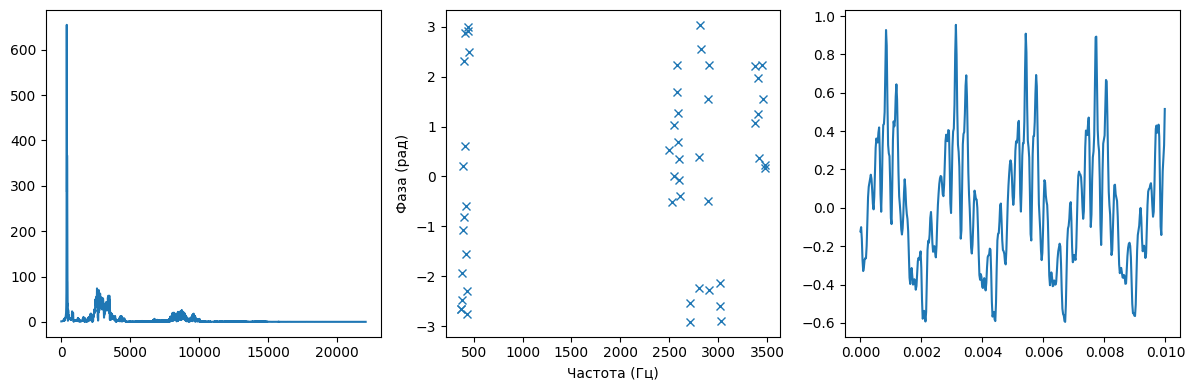

In [46]:
spectrum = segment.make_spectrum()
plot_three(spectrum, thresh=50)

### Обнуление фаз

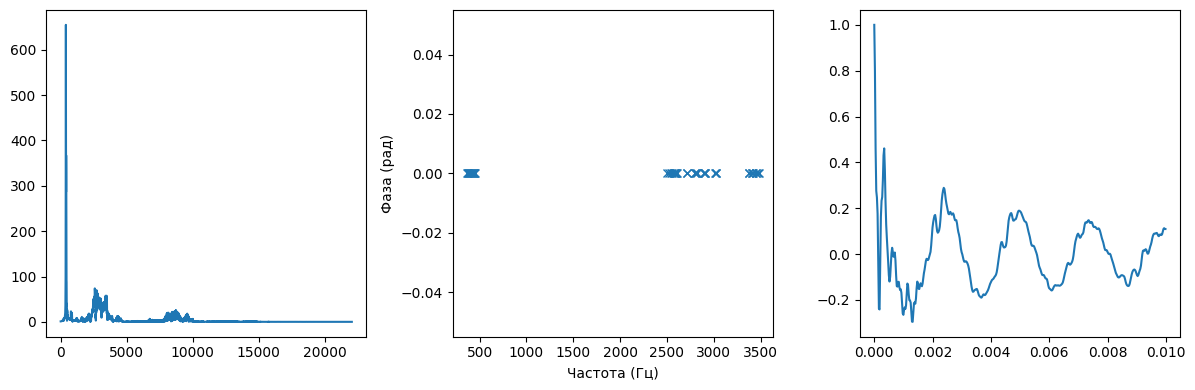

In [47]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

Обнуление фаз создаёт эффект «звона» (ringing), при котором громкость меняется во времени. Тем не менее, высота тона и тембр в целом сохраняются.

### Поворот фаз на 1 радиан

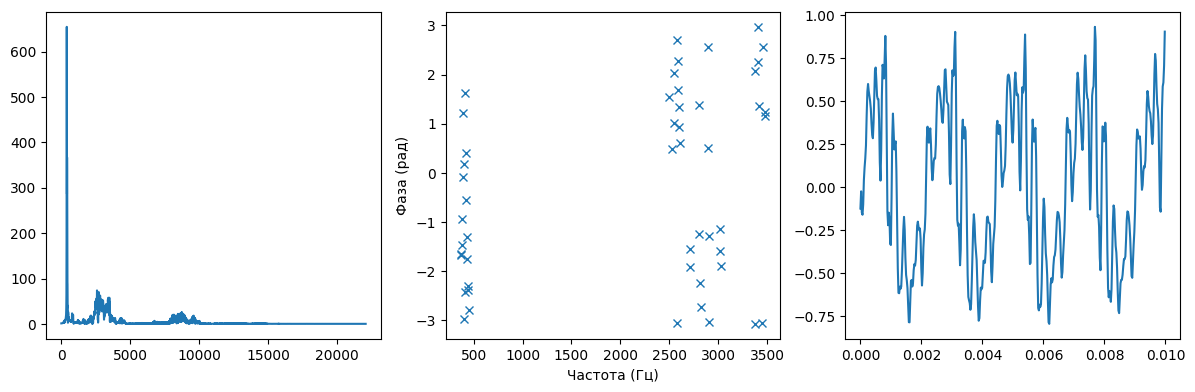

In [48]:
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

Поворот фаз не вызывает заметных изменений в восприятии.

### Случайные фазы

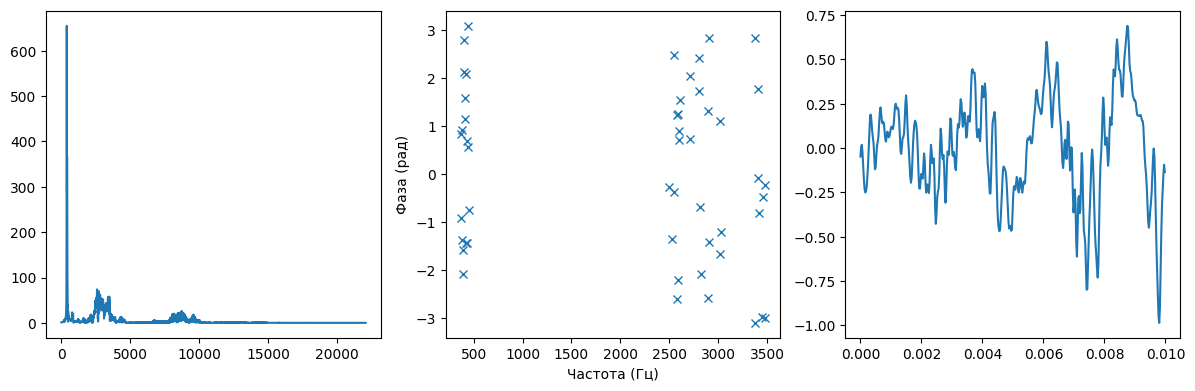

In [49]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Случайные фазы добавляют «дыхательный» оттенок (breathiness) и могут вызывать некоторый звон.